# Advanced: Add clouds to the simulation

For now, we will manually overwrite the water cloud file in the libradtran input.

In [1]:
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd

solar_config_path = Path('config/cloud_solar.yaml')
thermal_config_path = Path('config/cloud_thermal.yaml')
import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

N_timesteps = 1

ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2025-04-04T12:00:00', periods=N_timesteps, freq='s'),
        'latitude' : ('time', [51.3406321] * N_timesteps),
        'longitude' : ('time', [12.3747329] * N_timesteps),
        'altitude' : ('altitude', np.arange(0, 10, 0.5)),
    },
    data_vars={
        'surface_temperature' : ('time', [290] * N_timesteps),  # Kelvin
    }
)

# print("\nSimulation complete!")
# print(f"Dataset variables: {list(ds_sim.data_vars.keys())}")
# print(f"Dataset coordinates: {list(ds_sim.coords.keys())}")
# print(f"Dataset shape: {ds_sim.dims}")

## Water cloud: 

This is how a water cloud looks like in libradtra:
```bash
#      z     LWC    R_eff
#     (km)  (g/m^3) (um)  
      4.000     0    10.0     # The water cloud is located between
      3.000   1.0    10.0     # 2 and 4.0 km. The parameters may 
      2.000   1.0    10.0     # vary with altitude.
```

Let's write it to a file at `work/water_cloud.wc`.


In [21]:
wc_content = """#      z     LWC    R_eff
#     (km)  (g/m^3) (um)
    
    4.000     0    7.0
    3.800   5.0    9.0
    3.500   5.0    10.0
    3.200   5.0    10.0
    3.000   5.0    20.0
    2.800   5.0    17.0
    2.500   5.0    15.0
    2.100   5.0    10.0
    2.000   5.0    10.0
"""

wc_file_path = Path('work/water_cloud.wc')
wc_file_path.parent.mkdir(parents=True, exist_ok=True)
wc_file_path.write_text(wc_content)

print(f"Water cloud definition written to {wc_file_path}")

Water cloud definition written to work/water_cloud.wc


In [22]:
ds_sim_solar = ds.pyradtran.run_uvspec(
    config_path=solar_config_path,
    return_dataset=True,
    save_to_file=True,
    surface_temperature_var='surface_temperature',
    parameter_overrides={
        'wc_file 1D' : 'water_cloud.wc',  # Use the water cloud file
        #'wc_modify tau 10' : ''
    }
)

ds_sim_thermal = ds.pyradtran.run_uvspec(
    config_path=thermal_config_path,
    return_dataset=True,
    save_to_file=True,
    surface_temperature_var='surface_temperature',
    parameter_overrides={
        'wc_file 1D' : 'water_cloud.wc',  # Use the water cloud file
        #'wc_modify tau 10' : ''
    }
)


Text(0.5, 1.0, '')

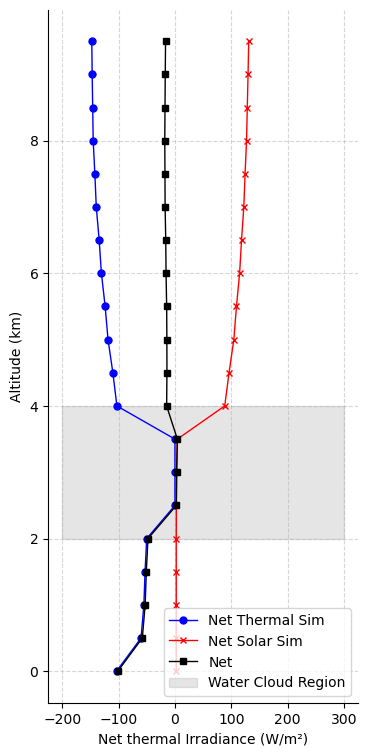

In [24]:
fig, ax = plt.subplots(figsize=(4, 9))

ds_sim_thermal.enet.sel(time='2025-04-04T12:00:00').plot(y='altitude', ax=ax, marker='o', color='blue', label='Net Thermal Sim', lw=1, markersize=5)
(ds_sim_solar.enet / 1e3).sel(time='2025-04-04T12:00:00').plot(y='altitude', ax=ax, marker='x', color='red', label='Net Solar Sim', lw=1, markersize=5)
net = ds_sim_solar.enet.sel(time='2025-04-04T12:00:00').values / 1e3 + ds_sim_thermal.enet.sel(time='2025-04-04T12:00:00').values
ax.plot(net, ds_sim_solar.altitude, color='black', label='Net', lw=1, marker='s', markersize=5)
# shade the region where the water cloud is present
ax.fill_betweenx(np.arange(2, 5), -200, 300, color='gray', alpha=0.2, label='Water Cloud Region')
ax.set_xlabel('Net thermal Irradiance (W/m²)')
ax.set_ylabel('Altitude (km)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('')



In [117]:
N_timesteps = 2
ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2020-04-03T12:00:00', periods=N_timesteps, freq='s'),
        'latitude' : ('time', [80.0] * N_timesteps),
        'longitude' : ('time', [0.0] * N_timesteps),
        'altitude' : ('altitude', np.arange(0, 10, 0.5)),
    },
    data_vars={
        'surface_temperature' : ('time', [273.15, 273.15-15]),  # #15°C cold sea-ice surface
        'albedo' : ('time', [0.2, 0.8]),  # Albedo for the surface
    }
)

ds


<xarray.Dataset> Size: 240B
Dimensions:              (time: 2, altitude: 20)
Coordinates:
  * time                 (time) datetime64[ns] 16B 2020-04-03T12:00:00 2020-0...
    latitude             (time) float64 16B 80.0 80.0
    longitude            (time) float64 16B 0.0 0.0
  * altitude             (altitude) float64 160B 0.0 0.5 1.0 1.5 ... 8.5 9.0 9.5
Data variables:
    surface_temperature  (time) float64 16B 273.1 258.1
    albedo               (time) float64 16B 0.2 0.8

In [118]:
# now, also write some ice cloud data
ic_content = """#      z     IWC    R_eff
#     (km)  (g/m^3) (um)
    4.000     0.02    20.0
    3.000     0.02    20.0
    2.500     0.02    20.0
    2.000     0.02    20.0
"""

ic_file_path = Path('work/ice_cloud.ic')
ic_file_path.parent.mkdir(parents=True, exist_ok=True)
ic_file_path.write_text(ic_content)

print(f"Ice cloud definition written to {ic_file_path}")

Ice cloud definition written to work/ice_cloud.ic


In [119]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import gcsfs
import os

# we use the GCSFileSystem to access the ERA5 data stored in Google Cloud Storage
gcs = gcsfs.GCSFileSystem(token='anon')
path = 'gs://gcp-public-data-arco-era5/ar/1959-2022-6h-128x64_equiangular_with_poles_conservative.zarr/'
full_era5 = xr.open_zarr(gcs.get_mapper(path), chunks='auto')
#full_era5.to_netcdf('../data/era5_6h_128x64.nc', engine='h5netcdf')

In [120]:
era5_to_sim = full_era5.rename({
    'sea_surface_temperature': 'surface_temperature',
    'temperature': 't',
    'specific_humidity': 'q',
    'geopotential': 'z',
    'level': 'pressure_level',
    'time' : 'valid_time',
})



### manually add ozone profile if not present
if 'o3' not in era5_to_sim.data_vars:
    # Use a constant profile for ozone, e.g., 300 DU
    # Convert DU to number density (1 DU = 2.687e19 molecules/m^2)
    # Assume a standard atmosphere for conversion
    altitude_km = era5_to_sim['z'] / 1000.0  # Convert geopotential height to km
    o3_profile = xr.DataArray(
        data=300e-6 * 2.687e19 * np.exp(-altitude_km / 8.5),  # Example exponential decay
        dims=era5_to_sim['z'].dims,
        coords=era5_to_sim['z'].coords,
        name='o3'
    )
    era5_to_sim = era5_to_sim.assign(o3=o3_profile)

era5_to_sim['total_cloud_cover'].sel(
    valid_time='2020-04-03T12:00:00',
    latitude=80.0,
    longitude=0.0,
    method='nearest'  # Use nearest neighbor interpolation for latitude and longitude
    ).load()

<xarray.DataArray 'total_cloud_cover' ()> Size: 4B
array(1., dtype=float32)
Coordinates:
    latitude    float64 8B 78.57
    longitude   float64 8B 0.0
    valid_time  datetime64[ns] 8B 2020-04-03T12:00:00
Attributes:
    long_name:      Total cloud cover
    short_name:     tcc
    standard_name:  cloud_area_fraction
    units:          (0 - 1)

(1000.0, 0.0)

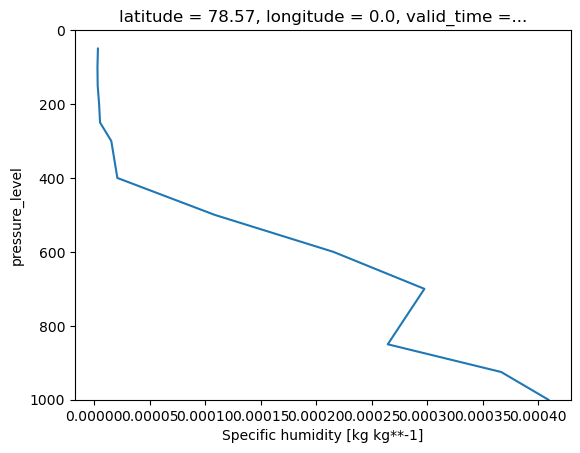

In [121]:
era5_to_sim.sel(
    valid_time='2020-04-03T12:00:00',
    latitude=80.0,
    longitude=0.0,
    method='nearest'  # Use nearest neighbor interpolation for latitude and longitude
    )['q'].plot(y='pressure_level')
plt.ylim(1000, 0)  # Invert y-axis for pressure levels

In [122]:
logging.getLogger('pyradtran').setLevel(logging.DEBUG)
ds_sim_solar = ds.pyradtran.run_uvspec(
    config_path=solar_config_path,
    return_dataset=True,
    save_to_file=True,
    surface_temperature_var='surface_temperature',
    albedo_var='albedo',
    era5_atmosphere=era5_to_sim,
    parameter_overrides={
        'wc_file 1D' : 'water_cloud.wc',  # Use the water cloud file
        'ic_file 1D' : 'ice_cloud.ic',  # Use the ice cloud file
    }
)

ds_sim_thermal = ds.pyradtran.run_uvspec(
    config_path=thermal_config_path,
    return_dataset=True,
    save_to_file=True,
    surface_temperature_var='surface_temperature',
    albedo_var='albedo',
    era5_atmosphere=era5_to_sim,
    parameter_overrides={
        'wc_file 1D' : 'water_cloud.wc',  # Use the water cloud file
        'ic_file 1D' : 'ice_cloud.ic',  # Use the ice cloud file
    }
)


2025-07-24 02:08:29,084 - pyradtran.interface - INFO - ERA5 atmosphere dataset validated with 13 pressure levels
2025-07-24 02:08:29,085 - pyradtran.interface - INFO - Altitude found as coordinate - using 20 levels for zout: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5
 9.  9.5]
2025-07-24 02:08:29,086 - pyradtran.interface - INFO - Auto-generating output path: work/xarray_example_20250724_020829.nc
2025-07-24 02:08:29,086 - pyradtran.interface - INFO - Creating ERA5 atmosphere files for simulation points...
2025-07-24 02:08:29,113 - pyradtran.io_old - INFO - 'co2' variable not found in dataset. Using constant 420 ppmv.
2025-07-24 02:08:29,114 - pyradtran.io_old - INFO - 'no2' variable not found in dataset. Using zero concentration.


2025-07-24 02:08:40,901 - pyradtran.io_old - INFO - Successfully created libRadtran atmosphere file at: work/era5_atmospheres/era5_atm_20200403_120000_80.00_0.00.dat
2025-07-24 02:08:40,903 - pyradtran.interface - DEBUG - Created ERA5 atmosphere file for 20200403_120000_80.00_0.00: work/era5_atmospheres/era5_atm_20200403_120000_80.00_0.00.dat
2025-07-24 02:08:40,958 - pyradtran.io_old - INFO - 'co2' variable not found in dataset. Using constant 420 ppmv.
2025-07-24 02:08:40,959 - pyradtran.io_old - INFO - 'no2' variable not found in dataset. Using zero concentration.
2025-07-24 02:08:51,169 - pyradtran.io_old - INFO - Successfully created libRadtran atmosphere file at: work/era5_atmospheres/era5_atm_20200403_120001_80.00_0.00.dat
2025-07-24 02:08:51,171 - pyradtran.interface - DEBUG - Created ERA5 atmosphere file for 20200403_120001_80.00_0.00: work/era5_atmospheres/era5_atm_20200403_120001_80.00_0.00.dat
2025-07-24 02:08:51,171 - pyradtran.interface - INFO - Running 2 simulations acro

Text(0.5, 1.0, 'sea-ice: $\\alpha=0.8$  $T_\\mathrm{S}=-15\\,$°C')

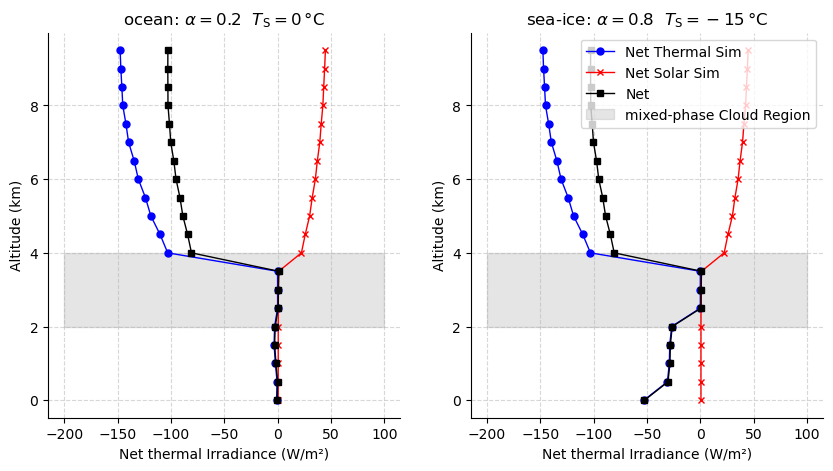

In [131]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ds_sim_thermal.enet.isel(time=0).plot(y='altitude', ax=ax[0], marker='o', color='blue', label='Net Thermal Sim', lw=1, markersize=5)
(ds_sim_solar/1e3).enet.isel(time=0).plot(y='altitude', ax=ax[0], marker='x', color='red', label='Net Solar Sim', lw=1, markersize=5)
fnet = ds_sim_solar.enet.isel(time=0).values / 1e3 + ds_sim_thermal.enet.isel(time=0).values
ax[0].plot(fnet, ds_sim_solar.altitude, color='black', label='Net', lw=1, marker='s', markersize=5)
# shade the region where the water cloud is present
ax[0].fill_betweenx(np.arange(2, 5), -200, 100, color='gray', alpha=0.2, label='Water Cloud Region')
ax[0].set_xlabel('Net thermal Irradiance (W/m²)')
ax[0].set_ylabel('Altitude (km)')
#ax[0].legend()
ax[0].spines[['top', 'right']].set_visible(False)
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].set_title(r'ocean: $\alpha=0.2$  $T_\mathrm{S}=0\,$°C')

ds_sim_thermal.enet.isel(time=1).plot(y='altitude', ax=ax[1], marker='o', color='blue', label='Net Thermal Sim', lw=1, markersize=5)
(ds_sim_solar/1e3).enet.isel(time=1).plot(y='altitude', ax=ax[1], marker='x', color='red', label='Net Solar Sim', lw=1, markersize=5)
fnet = ds_sim_solar.enet.isel(time=1).values / 1e3 + ds_sim_thermal.enet.isel(time=1).values
ax[1].plot(fnet, ds_sim_solar.altitude, color='black', label='Net', lw=1, marker='s', markersize=5)
# shade the region where the water cloud is present
ax[1].fill_betweenx(np.arange(2, 5), -200, 100, color='gray', alpha=0.2, label='mixed-phase Cloud Region')
ax[1].set_xlabel('Net thermal Irradiance (W/m²)')
ax[1].set_ylabel('Altitude (km)')
ax[1].legend()
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].set_title(r'sea-ice: $\alpha=0.8$  $T_\mathrm{S}=-15\,$°C')